# newspaper-ocr: an end-to-end walkthrough

This notebook walks through the recommended way to OCR historical newspaper pages with
[`newspaper-ocr`](https://github.com/nealcaren/newspaper-ocr), using the patterns that
work best in production:

1. **Layout detection** with DocLayout-YOLO
2. **Region-level OCR** with a vision-language model (GLM-OCR)
3. **A recovery ladder** — split tall regions that time out, then fall back to a second
   model (PaddleOCR-VL) for anything the primary still can't read, *do-no-harm*
4. **The `status` contract** — how to find the regions worth re-checking
5. **JSON output** and a **review site** for QA

Every code cell below is executed against a real 1902 newspaper page, so the outputs you
see are real model results, not mock-ups.

> **Hardware.** The VLM steps need a GPU. PaddleOCR-VL in particular needs an A100-class
> card — it returns empty output on some smaller GPUs. This notebook was executed on an
> NVIDIA A100.

## 1. Install

```bash
pip install "newspaper-ocr[doclayout,glm-ocr,paddleocr-vl]"
```

- `doclayout` — the DocLayout-YOLO detector
- `glm-ocr` — the GLM-OCR recognizer (primary)
- `paddleocr-vl` — the PaddleOCR-VL recognizer (fallback)

Other extras exist for line-level engines (`tesseract`, `kraken`, `trocr`, `lightonocr`)
and PDF input (`pdf`).

In [1]:
import newspaper_ocr as nocr
from newspaper_ocr.detectors import DETECTORS
from newspaper_ocr.recognizers import RECOGNIZERS
from newspaper_ocr.formatters import FORMATTERS

print("version         :", getattr(nocr, "__version__", "see pyproject"))
print("detectors       :", DETECTORS.list())
print("recognizers     :", RECOGNIZERS.list())
print("formatters      :", FORMATTERS.list())
print("pipeline ref tag:", nocr.PIPELINE_REFERENCE_TAG)
print("region statuses :", nocr.REGION_STATUSES)

version         : see pyproject
detectors       : ['as_yolo', 'doclayout_yolo', 'paddlex']
recognizers     : ['effocr', 'glm-ocr', 'kraken', 'lightonocr', 'paddleocr-vl', 'tesseract', 'tesseract-news', 'tesserocr', 'trocr']
formatters      : ['hocr', 'html', 'json', 'text', 'viewer']
pipeline ref tag: 2025-03-07-col-fix
region statuses : ('ok', 'timeout', 'repetition', 'error', 'chunked_partial')


## 2. Load a page

We use a page of *The Professional World* (Columbia, Missouri, 21 March 1902) — a dense
multi-column broadsheet, the case newspaper OCR is hardest on.

page size: (1966, 2800)


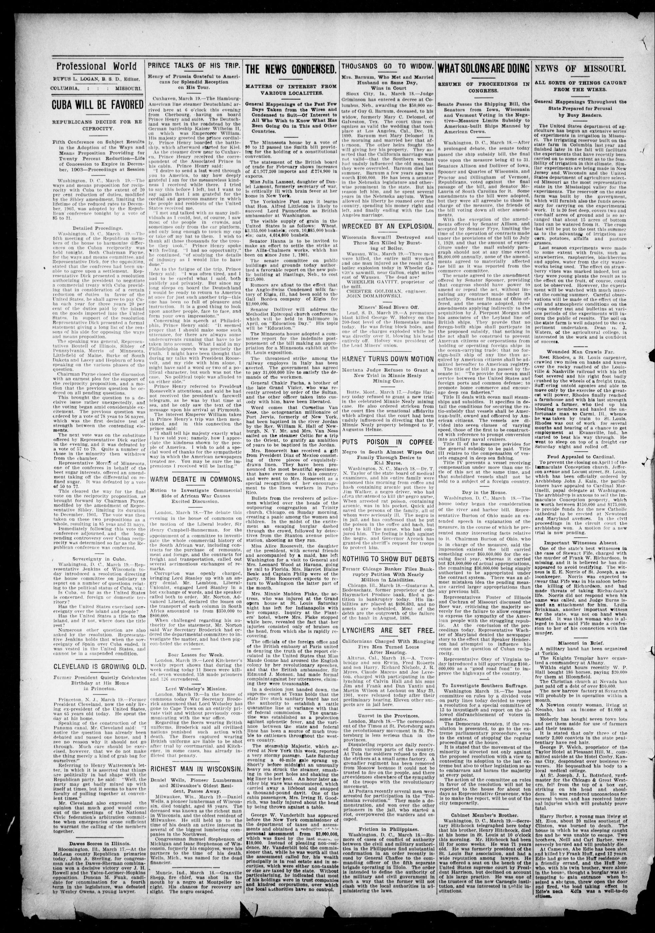

In [2]:
from pathlib import Path
from PIL import Image
from IPython.display import display

SAMPLE = Path("sample.jpg")          # swap in your own scan (jp2/jpg/png)
page = Image.open(SAMPLE).convert("RGB")
print("page size:", page.size)
display(page.resize((page.width // 3, page.height // 3)))

## 3. Layout detection

Detection is Phase 1: find the regions (articles, headlines, captions) before OCR. We use
**DocLayout-YOLO**, a region-only detector. It defaults to the 1280px checkpoint, which has
better recall on dense broadsheets.

The detector returns a `PageLayout` with one `Region` per detected block. Because it's
region-only it sets `lines_detected=False`, which tells the pipeline to send whole regions
to a region-level recognizer (rather than line-by-line).

In [3]:
from collections import Counter
from newspaper_ocr.detectors.doclayout import DocLayoutYoloDetector

detector = DocLayoutYoloDetector()          # variant="docstructbench-1280" by default
layout = detector.detect(page)

print("regions detected :", len(layout.regions))
print("labels           :", dict(Counter(r.label for r in layout.regions)))
print("lines_detected   :", layout.lines_detected, "(region-only detector)")

/work/users/n/c/ncaren/nocr-test/envs/nocr/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


regions detected : 153
labels           : {'plain_text': 119, 'title': 34}
lines_detected   : False (region-only detector)


Let's see what it found. We draw each region's box on the scan, colored by label.

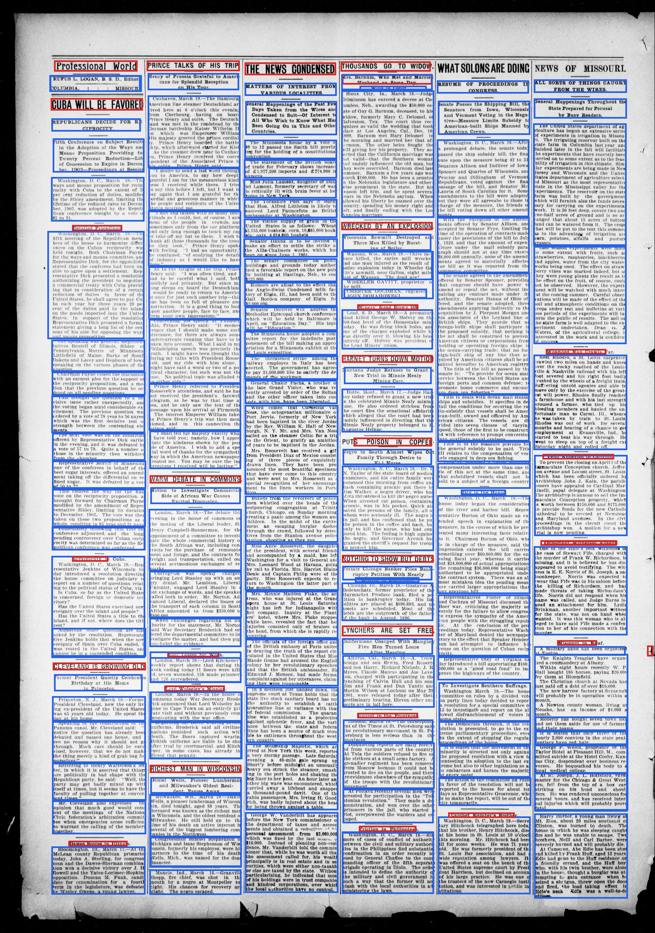

In [4]:
from PIL import ImageDraw

COLORS = {"plain_text": (37, 99, 235), "title": (220, 38, 38)}
overlay = page.copy()
draw = ImageDraw.Draw(overlay)
for r in layout.regions:
    x0, y0, x1, y1 = r.bbox.to_tuple()
    draw.rectangle([x0, y0, x1, y1], outline=COLORS.get(r.label, (16, 185, 129)), width=5)
display(overlay.resize((overlay.width // 3, overlay.height // 3)))

## 4. OCR with the recovery ladder (the recommended setup)

Phase 2 is recognition. For a region-level VLM the recommended configuration is a
three-step **recovery ladder**, all via `Pipeline`:

```python
Pipeline(recognizer="glm-ocr", fallback="paddleocr-vl", chunk_tall_regions=True)
```

- **primary** — GLM-OCR reads each region.
- **chunk_tall_regions** — if the primary *times out* on a tall region, the crop is split
  into overlapping vertical bands, each re-OCR'd with the same model, and the text stitched
  back together.
- **fallback** — any region still in a failure state is re-OCR'd by **PaddleOCR-VL**,
  *do-no-harm*: a timed-out/errored region takes any usable read, while a partial region is
  only overwritten by a clean read (the original is kept in `region.text_primary`).

We construct the recognizers explicitly so we can run GLM-OCR in local (GPU) mode. Here we
set a deliberately tight primary timeout so the ladder actually fires and you can see the
fallback recover regions — in production you'd use the default (25s).

In [5]:
from newspaper_ocr import Pipeline
from newspaper_ocr.recognizers.glm_ocr import GlmOcrRecognizer
from newspaper_ocr.recognizers.paddleocr_vl import PaddleOcrVlRecognizer

pipe = Pipeline(
    detector="doclayout_yolo",
    recognizer=GlmOcrRecognizer(mode="local", timeout=8, max_retries=0),  # tight, to show recovery
    fallback=PaddleOcrVlRecognizer(),                                     # PaddleOCR-VL-1.6
    chunk_tall_regions=True,
    text_cleaning=False,   # region-level VLM output is already clean
)

result = pipe.analyze(page)   # analyze() == run() without formatting; returns the PageLayout
print("regions:", len(result.regions))

Loading weights:   0%|          | 0/510 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/510 [00:00<02:30,  3.38it/s]

Loading weights:   0%|          | 2/510 [00:00<02:43,  3.11it/s]

Loading weights:   2%|▏         | 10/510 [00:00<00:26, 18.89it/s]

Loading weights:   3%|▎         | 16/510 [00:00<00:17, 28.08it/s]

...

Loading weights:  96%|█████████▌| 582/608 [00:04<00:00, 158.87it/s]

Loading weights:  99%|█████████▊| 599/608 [00:04<00:00, 143.34it/s]

Loading weights: 100%|██████████| 608/608 [00:04<00:00, 137.84it/s]

[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


regions: 42


## 5. Inspecting the results — the `status` contract

Every region carries a `status`. That's how you find the regions worth a second look
*without* re-reading the images:

- `ok` — clean read
- `timeout` / `error` — nothing usable (text is the `[OCR timeout]` placeholder or empty)
- `repetition` — the model looped; text was truncated
- `chunked_partial` — a tall region was split and some band still failed

When the fallback recovers a region, `region.engine` records which model did it and
`region.text_primary` preserves the primary's original text (so the swap is reversible).

In [6]:
from collections import Counter

print("final status   :", dict(Counter(r.status for r in result.regions)))
recovered = [r for r in result.regions if r.engine]
print("recovered by fallback:", len(recovered),
      "|", dict(Counter(r.engine for r in recovered)))
print("total characters:", sum(len(r.text or "") for r in result.regions))

final status   : {'ok': 42}
recovered by fallback: 2 | {'PaddleOcrVlRecognizer': 2}
total characters: 32402


In [7]:
# A region the primary failed on, recovered by the fallback (before -> after):
for r in recovered[:3]:
    print(f"[{r.id} {r.label}] engine={r.engine}")
    print("  primary :", repr((r.text_primary or "")[:90]))
    print("  final   :", repr((r.text or "").strip()[:90]))
    print()

[r15 plain_text] engine=PaddleOcrVlRecognizer
  primary : 'and accompanied by & mad, has left Washington for a visit to General and Mrs. Leonard Wood'
  final   : 'Word comes that Cornelius Van Ness, the octogenarian millionaire of Port Jervis, formerly '

[r36 plain_text] engine=PaddleOcrVlRecognizer
  primary : 'to provide funds for the new Catholic cathedral to be erected at Newstead and Maryland ave'
  final   : 'Reet Rhodes, a St. Louis carpenter, crawled two miles on hands and knees over the rocky ro'



## 6. JSON output — the stable contract

The JSON formatter is the downstream contract (review sites, article segmentation, LLM
enrichment). Each region is emitted with `id`, `label`, `bbox`, `text`, `status`,
`confidence`, and per-line detail when the recognizer is line-level.

In [8]:
import json
from newspaper_ocr.formatters import FORMATTERS

payload = json.loads(FORMATTERS.get("json")().format(result))
first = payload["regions"][0]
print(json.dumps({k: first[k] for k in ("id", "label", "bbox", "status", "confidence")}, indent=2))
print("text[:120]:", first["text"][:120])

{
  "id": "r0",
  "label": "title",
  "bbox": {
    "x0": 148,
    "y0": 181,
    "x1": 433,
    "y1": 693
  },
  "status": "ok",
  "confidence": 0.9292358756065369
}
text[:120]: Professional World

RUFUS L. LOGAN, B. S. D., Editor.

COLUMBIA, : : : MISSOURI.

CUBA WILL BE FAVORED

REPUBLICANS DECI


## 7. A review site for QA

`ReviewSite` writes a static OpenSeadragon site — the scan, clickable region boxes tinted
by status, a synced text pane, and a `manifest.json` carrying every region. It's the fastest
way to eyeball a run and spot the regions that need redoing.

`Pipeline.analyze` already gave us the `PageLayout`, so we can write the site without OCRing
the page twice.

In [9]:
from newspaper_ocr.viewer import ReviewSite

site = ReviewSite("review-site", title="Professional World, 1902-03-21")
site.add_page(result)
index = site.write()
manifest = json.loads((index.parent / "manifest.json").read_text())

print("wrote:", index)
print("files:", sorted(p.name for p in index.parent.iterdir()))
print("whole-issue status counts:", manifest["status_counts"])

wrote: review-site/index.html
files: ['index.html', 'manifest.json', 'page-001.html', 'scans']
whole-issue status counts: {'ok': 42}


Open `review-site/index.html` in a browser to inspect the page: click a region on the scan
to jump to its text, and regions are tinted by status so timeouts and loops stand out.

## 8. PDF input and batch processing

Most issues arrive as multi-page PDFs. `ocr_pdf` handles the awkward parts: it takes each
page from its **largest embedded image** (Google scans prepend a small "Digitized by
Google" strip, so `images[0]` is the wrong one), and `rotate=` fixes sideways broadsheets.

```python
pipe = Pipeline(recognizer="glm-ocr", fallback="paddleocr-vl",
                chunk_tall_regions=True, output="json")

# one formatted result per page
pages = pipe.ocr_pdf("issue.pdf", rotate=90)

# or stream pages so a whole issue isn't resident in memory:
from newspaper_ocr.pdf import page_images
for i, image in enumerate(page_images("issue.pdf", rotate=90)):
    Path(f"page-{i:03d}.json").write_text(pipe.run(image))
```

Requires `pip install "newspaper-ocr[pdf]"`. (Not executed here — no PDF in this notebook.)

## Best practices recap

- **Detect, then OCR.** Use a layout detector so each region is OCR'd in context; DocLayout-YOLO
  (1280px) is a strong default for dense pages.
- **Use the recovery ladder for VLM OCR:** `chunk_tall_regions=True` + a `fallback` recognizer.
  A single tight timeout plus a second model recovers the long tail that one model alone drops.
- **Trust the `status` field, not the text length.** Filter `status != "ok"` to find regions to
  re-check; `engine`/`text_primary` tell you what the fallback changed.
- **Keep JSON as your contract** and use the review site to QA before committing a run.
- **PaddleOCR-VL wants an A100.** It's the intended fallback but degrades on smaller GPUs.